---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Manipulação de arrays e janelas de dados |
| `pandas` | Leitura do CSV de clima |
| `matplotlib` | Visualizações e gráficos |
| `scikit-learn` | Escaladores e métricas de avaliação |
| `torch` | Carregamento de pesos e inferência |

In [ ]:
# %pip install numpy pandas matplotlib scikit-learn torch --quiet

## Aula 05: Consumindo Modelos LSTM Salvos

No notebook de treino (`aula5_redes_neurais_lstm.ipynb`) treinamos dois modelos LSTM e salvamos seus pesos em disco com `torch.save`. Este notebook demonstra como **carregar e usar esses modelos sem re-treinar**  simulando um fluxo de deploy real.

### Por que isso importa?

Treinar uma rede pode levar horas. Em produção, queremos:
- Carregar os pesos uma única vez na inicialização do sistema
- Fazer inferências rápidas sem recalcular gradientes
- Garantir que a normalização de entrada seja **idêntica** à usada no treino

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Como `torch.save` / `torch.load` funcionam |
| **2** | Caso 1  Previsão de temperatura (regressão) |
| **3** | Caso 2  Reconhecimento de atividade humana (classificação) |
| **4** | Resumo  fluxo completo de treino → deploy |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")

PyTorch 2.11.0 | device: cpu


---

## 1. Como Funciona o Salvamento de Modelos

O PyTorch oferece a função `torch.save` para persistir qualquer objeto Python (incluindo pesos de modelos) em disco.

### Estratégia recomendada: salvar um *checkpoint*

```python
checkpoint = {
    'model_state_dict': model.state_dict(),  # somente os pesos
    'scaler':           scaler,              # normalização usada no treino
    'input_size':       8,                   # metadados da arquitetura
}
torch.save(checkpoint, 'models/meu_modelo.pth')
```

### Para carregar

```python
ckpt = torch.load('models/meu_modelo.pth', map_location=device)
model = MinhaRede(input_size=ckpt['input_size'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()  # desliga dropout e batchnorm
```

| O que salvar | Por quê |
|---|---|
| `model.state_dict()` | Apenas os tensores de pesos  portável entre versões |
| Escaladores (`scaler`) | A normalização de entrada deve ser idêntica ao treino |
| Metadados da arquitetura | Para recriar o modelo com os parâmetros corretos |

> **Atenção:** nunca salve o objeto modelo inteiro com `torch.save(model, ...)`. Isso cria dependência do caminho exato da classe Python e quebra facilmente ao mover o código.

---

## 2. Caso 1  Previsão de Temperatura (Regressão)

Carregamos o modelo `lstm_temperatura.pth` e fazemos previsões sobre os dados de teste **sem re-treinar**.

**Dataset:** Jena Climate 2009-2016 (estação meteorológica do Instituto Max Planck, Alemanha)

**Objetivo:** prever a temperatura do ar `T (degC)` a partir de uma janela de 24 horas de 8 variáveis meteorológicas.

### 2.1 Definição da Arquitetura

A **mesma** classe `PrevisaoLSTM` precisa ser declarada aqui para que `load_state_dict` funcione.
Os hiperparâmetros (hidden_size, num_layers) são lidos do checkpoint  não há números mágicos.

In [2]:
class PrevisaoLSTM(nn.Module):
    """LSTM many-to-one para regressão de temperatura."""

    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

### 2.2 Carregando o Checkpoint

In [3]:
from sklearn.preprocessing import StandardScaler

ckpt_reg = torch.load("models/lstm_temperatura.pth", map_location=device, weights_only=False)

# Recupera metadados salvos junto com os pesos
SEQ_LEN  = ckpt_reg["seq_len"]      # 24 horas de histórico
FEATURES = ckpt_reg["features"]     # lista com os nomes das 8 colunas
TARGET   = "T (degC)"
scaler_X = ckpt_reg["scaler_X"]
scaler_y = ckpt_reg["scaler_y"]

# Reconstrói o modelo com os parâmetros do checkpoint
modelo_reg = PrevisaoLSTM(
    input_size  = ckpt_reg["input_size"],
    hidden_size = ckpt_reg["hidden_size"],
    num_layers  = ckpt_reg["num_layers"],
).to(device)

modelo_reg.load_state_dict(ckpt_reg["model_state_dict"])
modelo_reg.eval()   # desliga dropout

print(f"Checkpoint carregado com sucesso!")
print(f"  seq_len  : {SEQ_LEN} horas de histórico")
print(f"  features : {FEATURES}")
print(modelo_reg)

Checkpoint carregado com sucesso!
  seq_len  : 24 horas de histórico
  features : ['p (mbar)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)', 'wv (m/s)', 'wd (deg)']
PrevisaoLSTM(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 2.3 Preparando os Dados de Teste

Carregamos os dados originais e aplicamos **o mesmo escalador** salvo no checkpoint.
Os últimos 10% das janelas são usados como conjunto de teste.

In [4]:
df = pd.read_csv("data/jena/jena_climate_2009_2016.csv")
df = df.iloc[::6].reset_index(drop=True)          # 10 min → 1 hora
df["wv (m/s)"]      = df["wv (m/s)"].replace(-9999.0, np.nan)
df["max. wv (m/s)"] = df["max. wv (m/s)"].replace(-9999.0, np.nan)
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

feat_norm = scaler_X.transform(df[FEATURES].values)
targ_norm = scaler_y.transform(df[[TARGET]].values).ravel()

X_all = np.array([feat_norm[i : i + SEQ_LEN] for i in range(len(feat_norm) - SEQ_LEN)])
y_all = targ_norm[SEQ_LEN:]

n_test = int(len(X_all) * 0.10)
X_te   = torch.tensor(X_all[-n_test:], dtype=torch.float32).to(device)
y_te   = y_all[-n_test:]

print(f"Shape  : {X_te.shape}  →  (amostras, seq_len={SEQ_LEN}, features={len(FEATURES)})")

Shape  : torch.Size([7006, 24, 8])  →  (amostras, seq_len=24, features=8)


### 2.4 Inferência e Resultados

Métrica                   Valor
----------------------------------------------------
RMSE (°C)                0.7899
MAE  (°C)                0.5776
R²                       0.9899


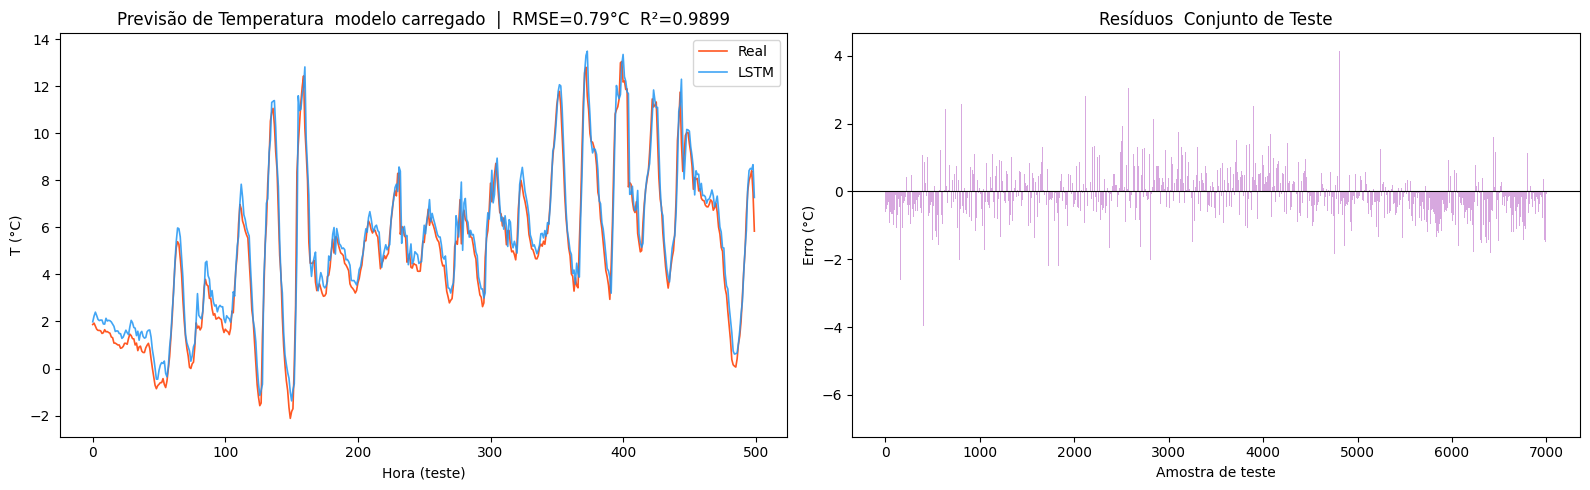

In [5]:
with torch.no_grad():
    pred_norm = modelo_reg(X_te).cpu().numpy()

def desnorm(arr):
    return scaler_y.inverse_transform(arr.reshape(-1, 1)).flatten()

pred_real = desnorm(pred_norm)
real      = desnorm(y_te)

rmse = np.sqrt(np.mean((real - pred_real) ** 2))
mae  = np.mean(np.abs(real - pred_real))
r2   = 1 - np.sum((real - pred_real) ** 2) / np.sum((real - real.mean()) ** 2)

print("=" * 52)
print(f"{'Métrica':<20} {'Valor':>10}")
print("-" * 52)
print(f"{'RMSE (°C)':<20} {rmse:>10.4f}")
print(f"{'MAE  (°C)':<20} {mae:>10.4f}")
print(f"{'R²':<20} {r2:>10.4f}")
print("=" * 52)

n_plot = min(500, len(real))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(real[:n_plot],      label="Real", color="#FF5722", lw=1.2)
ax.plot(pred_real[:n_plot], label="LSTM", color="#2196F3", lw=1.2, alpha=0.85)
ax.set_title(f"Previsão de Temperatura  modelo carregado  |  RMSE={rmse:.2f}°C  R²={r2:.4f}",
             fontsize=12)
ax.set_ylabel("T (°C)"); ax.set_xlabel("Hora (teste)"); ax.legend()

ax = axes[1]
residuos = real - pred_real
ax.bar(range(len(residuos)), residuos, color="#9C27B0", alpha=0.4, width=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Resíduos  Conjunto de Teste", fontsize=12)
ax.set_ylabel("Erro (°C)"); ax.set_xlabel("Amostra de teste")

plt.tight_layout(); plt.show()

---

## 3. Caso 2  Reconhecimento de Atividade Humana (Classificação)

Carregamos `lstm_har.pth` e classificamos sequências de 128 timesteps de sensor.

**Dataset:** UCI HAR  acelerômetro e giroscópio de smartphone (50 Hz)

**Objetivo:** identificar qual das 6 atividades o usuário realiza a partir de uma janela de 2,56 segundos.

### 3.1 Definição da Arquitetura

In [ ]:
class ClassificacaoLSTM(nn.Module):
    """LSTM many-to-one para classificação de atividade humana."""

    def __init__(self, input_size=9, hidden_size=128, num_layers=2,
                 dropout=0.3, n_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))

### 3.2 Carregando o Checkpoint

In [ ]:
ckpt_clf = torch.load("models/lstm_har.pth", map_location=device, weights_only=False)

LABELS     = ckpt_clf["activity_labels"]
scaler_clf = ckpt_clf["scaler_clf"]

modelo_clf = ClassificacaoLSTM(
    input_size  = ckpt_clf["input_size"],
    hidden_size = ckpt_clf["hidden_size"],
    num_layers  = ckpt_clf["num_layers"],
    n_classes   = ckpt_clf["num_classes"],
).to(device)

modelo_clf.load_state_dict(ckpt_clf["model_state_dict"])
modelo_clf.eval()

print("Checkpoint HAR carregado com sucesso!")
print(f"  Atividades : {LABELS}")
print(modelo_clf)

### 3.3 Carregando os Dados de Teste

In [ ]:
HAR_PATH = "data/har/UCI HAR Dataset"
CANAIS   = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def carregar_har(split="test"):
    pasta = os.path.join(HAR_PATH, split, "Inertial Signals")
    sinal = np.stack(
        [np.loadtxt(os.path.join(pasta, f"{c}_{split}.txt")) for c in CANAIS],
        axis=-1
    )  # (N, 128, 9)
    labels = np.loadtxt(os.path.join(HAR_PATH, split, f"y_{split}.txt"), dtype=int) - 1
    return sinal, labels

X_te_raw, y_te_c = carregar_har("test")
N_te, T, C = X_te_raw.shape

# Normaliza com o escalador salvo (fit foi feito apenas no treino)
X_te_norm = scaler_clf.transform(X_te_raw.reshape(-1, C)).reshape(N_te, T, C)
X_te_t    = torch.tensor(X_te_norm, dtype=torch.float32).to(device)

print(f"Shape : {X_te_t.shape}  →  (amostras, {T} timesteps, {C} canais)")

### 3.4 Inferência em Lote e Acurácia

In [ ]:
loader_te = DataLoader(TensorDataset(X_te_t), batch_size=256)

logits_all = []
with torch.no_grad():
    for (xb,) in loader_te:
        logits_all.append(modelo_clf(xb).cpu())

logits_all = torch.cat(logits_all, dim=0)     # (N_te, 6)
preds      = logits_all.argmax(dim=1).numpy()

acuracia = (preds == y_te_c).mean() * 100
print(f"Acurácia no conjunto de teste: {acuracia:.2f}%")

### 3.5 Predição de uma Única Amostra

Demonstração do uso do modelo em produção: recebe uma janela de 128 passos e retorna a atividade predita com as probabilidades por classe.

In [ ]:
idx     = np.random.randint(0, len(X_te_norm))
amostra = torch.tensor(X_te_norm[idx : idx + 1], dtype=torch.float32).to(device)

with torch.no_grad():
    logits  = modelo_clf(amostra)
    probs   = torch.softmax(logits, dim=1)[0]
    predito = int(logits.argmax(dim=1).item())

real_label = y_te_c[idx]

print(f"Amostra #{idx}")
print(f"  Real    : {LABELS[real_label]}")
print(f"  Predito : {LABELS[predito]}")
print()
print("Probabilidades por classe:")
for nome, p in zip(LABELS, probs):
    barra = chr(9608) * int(p.item() * 30)
    print(f"  {nome:<22} {p.item()*100:5.1f}%  {barra}")

fig, ax = plt.subplots(figsize=(9, 4))
cores = ["#4CAF50" if i == predito else "#90CAF9" for i in range(len(LABELS))]
ax.bar(LABELS, probs.numpy(), color=cores, edgecolor="white")
ax.set_ylim(0, 1)
ax.set_ylabel("Probabilidade")
ax.set_title(f"Predito: {LABELS[predito]}  |  Real: {LABELS[real_label]}", fontsize=13)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout(); plt.show()

### 3.6 Matriz de Confusão

In [ ]:
matriz = confusion_matrix(y_te_c, preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=LABELS)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
ax.set_title("Matriz de Confusão  modelo carregado", fontsize=13)
plt.tight_layout(); plt.show()

print("\nAcurácia por classe:")
for nome, acc_i in zip(LABELS, matriz.diagonal() / matriz.sum(axis=1)):
    print(f"  {nome:<22}: {acc_i*100:.1f}%")

---

## 4. Comparativo e Próximos Passos

### Treino vs. Inferência

| Etapa | Notebook de Treino | Este Notebook |
|---|---|---|
| Carrega dados | ✓ | ✓ (apenas para teste) |
| Define arquitetura | ✓ | ✓ (obrigatório para `load_state_dict`) |
| Treina o modelo | ✓ | ✗ |
| Salva checkpoint | `torch.save(...)` | ✗ |
| Carrega checkpoint | ✗ | `torch.load(...)` |
| Faz inferência | ✗ | ✓ |

### Fluxo completo de deploy

```
1. Treinar  →  torch.save(checkpoint, 'modelo.pth')
2. Empacotar: arquivo .pth + definição da classe do modelo
3. Carregar:  torch.load → model.load_state_dict → model.eval()
4. Inferir:   with torch.no_grad(): output = model(input)
```

### Próximos Passos

| Tópico | O que resolve |
|--------|---------------|
| **TorchScript / ONNX** | Exportar o modelo para ambientes sem PyTorch |
| **FastAPI / Flask** | Embrulhar o modelo em uma API REST |
| **Quantização** | Reduzir o tamanho do modelo para dispositivos edge |